In [ ]:
!pip install inference-sdk
!pip install opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.13.0.92
    Uninstalling opencv-python-4.13.0.92:
      Successfully uninstalled opencv-python-4.13.0.92


In [ ]:
from inference_sdk import InferenceHTTPClient
from google.colab import files
import cv2
from google.colab.patches import cv2_imshow

In [ ]:
CLIENT = InferenceHTTPClient(
    api_url="https://serverless.roboflow.com",
    api_key="kqvAIVqKjU0Jmp5Ip0JR"
)

In [ ]:
uploaded = files.upload()

image_name = list(uploaded.keys())[0]

print("Uploaded image:", image_name)

Saving 1.jpeg to 1.jpeg
Uploaded image: 1.jpeg


In [ ]:
result = CLIENT.infer(
    image_name,
    model_id="container-damage-detection-uekkr/1"
)

print(result)

{'inference_id': 'b285bdd4-a63f-4598-8ba0-22b9d7c4c054', 'time': 0.18527141599997776, 'image': {'width': 265, 'height': 190}, 'predictions': [{'x': 124.5, 'y': 76.5, 'width': 179.0, 'height': 57.0, 'confidence': 0.8504420518875122, 'class': 'Dent', 'class_id': 1, 'detection_id': 'dad8ed0d-69cc-47a4-9c3e-4b81e7f63597'}, {'x': 243.5, 'y': 89.0, 'width': 21.0, 'height': 142.0, 'confidence': 0.7897642850875854, 'class': 'Rust', 'class_id': 4, 'detection_id': 'eb034692-3dff-4a11-a277-e1bf302b053d'}, {'x': 117.0, 'y': 134.5, 'width': 162.0, 'height': 33.0, 'confidence': 0.7695292830467224, 'class': 'Deframe', 'class_id': 0, 'detection_id': '199755fd-b7c8-43e1-8db3-0cce49382a20'}, {'x': 176.5, 'y': 136.0, 'width': 9.0, 'height': 10.0, 'confidence': 0.7282887697219849, 'class': 'Rust', 'class_id': 4, 'detection_id': 'afe48128-95a7-4d7c-8465-485dd63bebb1'}, {'x': 26.0, 'y': 95.0, 'width': 8.0, 'height': 48.0, 'confidence': 0.5103874802589417, 'class': 'Rust', 'class_id': 4, 'detection_id': 'b9f

In [ ]:
def classify_condition(predictions):

    if len(predictions) == 0:
        return "Safe"

    for p in predictions:
        label = p["class"].lower()

        if "dent" in label:
            return "Faulty"

        if "rust" in label or "hole" in label:
            return "Damaged"

    return "Damaged"

In [ ]:
condition = classify_condition(result["predictions"])

print("Container Condition:", condition)

Container Condition: Faulty


In [ ]:
image = cv2.imread(image_name)

for pred in result["predictions"]:

    x = int(pred["x"])
    y = int(pred["y"])
    w = int(pred["width"])
    h = int(pred["height"])

    label = pred["class"].capitalize()
    confidence = pred["confidence"]

    # convert center → box corners
    x1 = int(x - w/2)
    y1 = int(y - h/2)
    x2 = int(x + w/2)
    y2 = int(y + h/2)

    # draw bounding box
    cv2.rectangle(image, (x1,y1), (x2,y2), (0,0,255), 2)

    text = f"{label} {confidence:.2f}"

    # get brightness of area behind label
    roi = image[max(0,y1-20):y1, x1:x1+100]

    if roi.size != 0:
        brightness = roi.mean()
    else:
        brightness = 255

    # choose contrast color
    if brightness > 127:
        text_color = (0,0,0)      # dark text
        bg_color = (255,255,255)  # light background
    else:
        text_color = (255,255,255)
        bg_color = (0,0,0)

    # small text
    font_scale = 0.5
    thickness = 1

    (text_w, text_h), _ = cv2.getTextSize(
        text, cv2.FONT_HERSHEY_SIMPLEX, font_scale, thickness
    )

    # draw background box
    cv2.rectangle(
        image,
        (x1, y1 - text_h - 5),
        (x1 + text_w + 5, y1),
        bg_color,
        -1
    )

    # draw text
    cv2.putText(
        image,
        text,
        (x1+2, y1-3),
        cv2.FONT_HERSHEY_SIMPLEX,
        font_scale,
        text_color,
        thickness
    )

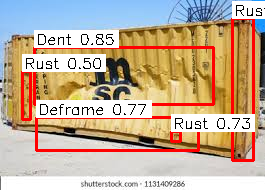

In [ ]:
cv2_imshow(image)